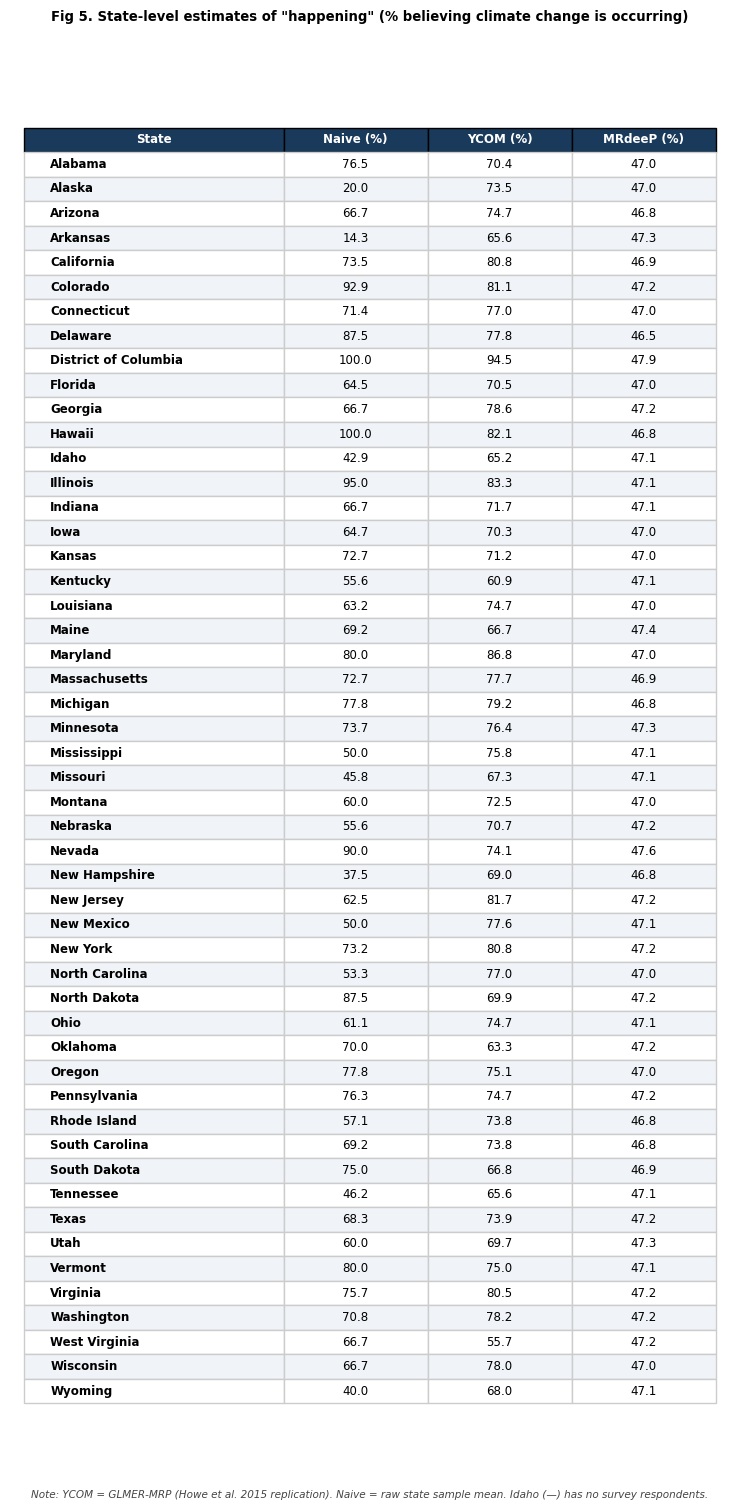

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/fig5_happening_comparison.png


In [1]:
# Fig 5 — State-level "happening" estimates: Naive vs YCOM (GLMER-MRP) vs MRdeeP

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
from pathlib import Path

EST = Path(os.getcwd()).parent.parent / "outputs" / "estimates"

baseline = pd.read_csv(EST / "baseline_state_estimates.csv")[["state_fips","state_name","estimate"]].rename(columns={"estimate":"Naive"})
glmer    = pd.read_csv(EST / "glmer_mrp_state_estimates.csv")[["state_fips","estimate"]].rename(columns={"estimate":"YCOM"})
mrdeep   = pd.read_csv(EST / "mrdeep_state_estimates.csv")[["state_fips","estimate"]].rename(columns={"estimate":"MRdeeP"})

df = (baseline
      .merge(glmer,  on="state_fips", how="outer")
      .merge(mrdeep, on="state_fips", how="outer")
      .sort_values("state_name")
      .reset_index(drop=True))

# Express as percentages, 1 decimal place
for col in ["Naive", "YCOM", "MRdeeP"]:
    df[col] = (df[col] * 100).round(1)

df["Naive"] = df["Naive"].apply(lambda x: f"{x:.1f}" if pd.notna(x) else "—")

# ── Draw table ───────────────────────────────────────────────────────────────
nrows = len(df)
fig_height = 0.27 * nrows + 1.2

fig, ax = plt.subplots(figsize=(7.5, fig_height))
ax.axis("off")

col_labels = ["State", "Naive (%)", "YCOM (%)", "MRdeeP (%)"]
cell_text  = df[["state_name","Naive","YCOM","MRdeeP"]].values.tolist()
cell_text  = [[row[0], row[1],
               f"{row[2]:.1f}" if pd.notna(row[2]) else "—",
               f"{row[3]:.1f}" if pd.notna(row[3]) else "—"]
              for row in cell_text]

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.18)

# Header style
for j in range(4):
    tbl[0, j].set_facecolor("#1a3a5c")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Alternating row shading
for i in range(1, nrows + 1):
    bg = "#f0f4f8" if i % 2 == 0 else "white"
    for j in range(4):
        tbl[i, j].set_facecolor(bg)
        tbl[i, j].set_edgecolor("#cccccc")

# Bold state column
for i in range(1, nrows + 1):
    tbl[i, 0].set_text_props(ha="left", fontweight="bold")
    tbl[i, 0]._loc = "left"

col_widths = [0.36, 0.20, 0.20, 0.20]
for j, w in enumerate(col_widths):
    for i in range(nrows + 1):
        tbl[i, j].set_width(w)

fig.suptitle(
    'Fig 5. State-level estimates of "happening" (% believing climate change is occurring)',
    fontsize=9.5, fontweight="bold", y=0.995, ha="center"
)
fig.text(0.5, 0.001,
         "Note: YCOM = GLMER-MRP (Howe et al. 2015 replication). "
         "Naive = raw state sample mean. Idaho (—) has no survey respondents.",
         ha="center", fontsize=7.5, style="italic", color="#444444")

plt.tight_layout()
out_path = EST / "fig5_happening_comparison.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")